In [2]:
!pip install optuna
!pip install shap

In [3]:
#Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import shap
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.INFO)

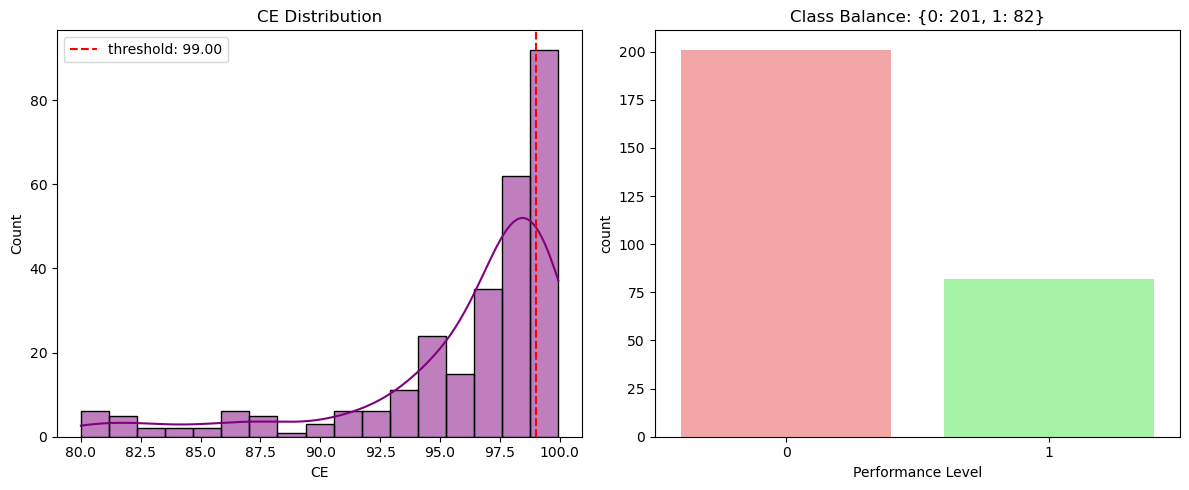

Dimensiones Train: (226, 13)
Dimensiones Test:  (57, 13)


In [4]:
ruta_archivo = r"C:\Users\Sergi\Desktop\Investigacion de materiales\Codigo definitivo\bdelectrolitos.csv"

df = pd.read_csv(ruta_archivo)
df = df.drop_duplicates()
df = df.sample(frac=1, random_state=22).reset_index(drop=True)

#Umbral y Variable Objetivo
UMBRAL = 99 # 2 es para 99% de Eficiencia Coulombica
df["desempeño"] = (df["CE"] >= UMBRAL).astype(int)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=df, x="CE", kde=True, color="purple", ax=axes[0])
axes[0].axvline(UMBRAL, color='red', linestyle='--', label=f'threshold: {UMBRAL:.2f}')
axes[0].set_title("CE Distribution")
axes[0].legend()

#Balance de Clases
conteo = df["desempeño"].value_counts()
sns.countplot(x="desempeño", data=df, palette=["#ff9999", "#99ff99"], ax=axes[1])
axes[1].set_title(f"Class Balance: {conteo.to_dict()}")
axes[1].set_xlabel("Performance Level")  # Nuevo nombre del eje X
plt.tight_layout()
plt.show()

#Separar Datos
cols_drop = ["Electrolyte", "CE", "LCE", "desempeño"]
X = df.drop(columns=[c for c in cols_drop if c in df.columns])
y = df["desempeño"]
feature_names = X.columns.tolist()

#Split estratificado para mantener proporcion de clases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Dimensiones Train: {X_train.shape}")
print(f"Dimensiones Test:  {X_test.shape}")
#guardar las curvas ROC de todos los modelos
resultados_roc = {}

In [5]:
fig.savefig("distribucion_lce.png", dpi=300, bbox_inches="tight")

VERIFICACIÓN DE PROPORCIONES
            Train %    Test %
desempeño                    
0          0.712389  0.701754
1          0.287611  0.298246
VERIFICACIÓN VISUAL PCA 2D


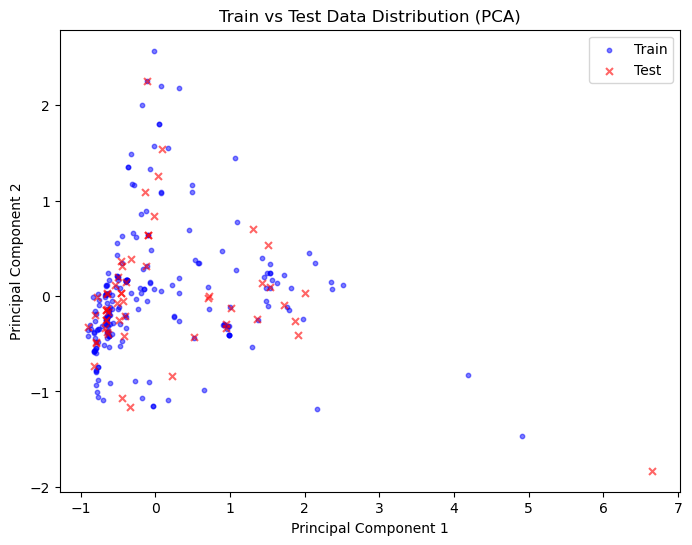

COMPARACION DE DISTRIBUCIONES


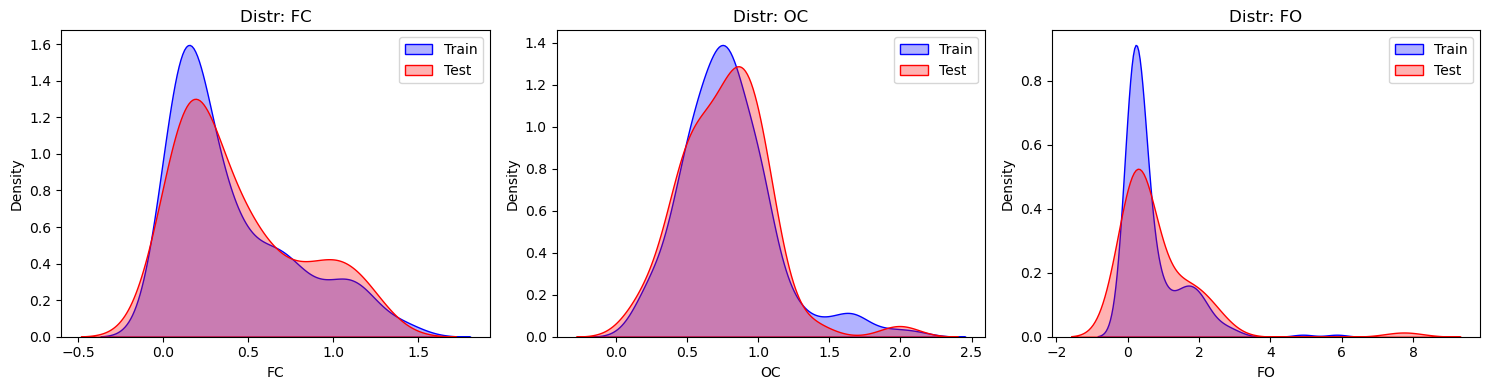

In [7]:
from sklearn.decomposition import PCA

def auditar_particion(X_train, y_train, X_test, y_test):
    print("VERIFICACIÓN DE PROPORCIONES")
    prop_train = y_train.value_counts(normalize=True)
    prop_test = y_test.value_counts(normalize=True)
    
    comp = pd.DataFrame({"Train %": prop_train, "Test %": prop_test})
    print(comp)
    print("VERIFICACIÓN VISUAL PCA 2D")
    #Reducir todas las features a 2 dimensiones para ver si se mezclan
    pca = PCA(n_components=2)
    #PCA con todo el conjunto
    X_all_pca = pca.fit_transform(pd.concat([X_train, X_test]))
    train_pca = X_all_pca[:len(X_train)]
    test_pca = X_all_pca[len(X_train):]
    
    plt.figure(figsize=(8, 6))
    plt.scatter(train_pca[:, 0], train_pca[:, 1], c='blue', alpha=0.5, label='Train', s=10)
    plt.scatter(test_pca[:, 0], test_pca[:, 1], c='red', alpha=0.6, label='Test', s=25, marker='x')
    plt.title("Train vs Test Data Distribution (PCA)")
    plt.legend()
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.savefig("PCA",dpi=300, bbox_inches="tight")
    plt.show()
    print("COMPARACION DE DISTRIBUCIONES")
    #comparar las 3 primeras columnas
    cols_to_plot = X_train.select_dtypes(include=np.number).columns[:3] 
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, col in enumerate(cols_to_plot):
        sns.kdeplot(X_train[col], ax=axes[i], color='blue', label='Train', fill=True, alpha=0.3)
        sns.kdeplot(X_test[col], ax=axes[i], color='red', label='Test', fill=True, alpha=0.3)
        axes[i].set_title(f"Distr: {col}")
        axes[i].legend()
    plt.tight_layout()
    plt.show()

#EJECUTAR
auditar_particion(X_train, y_train, X_test, y_test)

In [8]:
fig.savefig("distribucion_lce.png", dpi=300, bbox_inches="tight")

In [9]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
#nombres de las nuevas variables x1^2, x1*x2
feature_names_poly = poly.get_feature_names_out(X.columns)
print(f"Nuevas dimensiones con polinomios (Train): {X_train_poly.shape}")

Nuevas dimensiones con polinomios (Train): (226, 104)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

#Escalado OBLIGATORIO para Lasso
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

#Aplicar Lasso (Logistic Regression con penalización L1)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=.5, random_state=42)
lasso.fit(X_train_scaled, y_train)
coeficientes = pd.Series(lasso.coef_[0], index=feature_names_poly)
importantes = coeficientes.abs().sort_values(ascending=False)
#Seleccionar las 20 más importantes
top_20_features = importantes.head(20).index.tolist()
X_train_final = pd.DataFrame(X_train_poly, columns=feature_names_poly)[top_20_features]
X_test_final = pd.DataFrame(X_test_poly, columns=feature_names_poly)[top_20_features]

print(f"Variables seleccionadas: {top_20_features}")
print(f"Nueva forma de X_train: {X_train_final.shape}")
n_eliminadas = (coeficientes == 0).sum()
print(f"Lasso eliminó {n_eliminadas} variables de las {len(coeficientes)} originales.")

Variables seleccionadas: ['sO C', 'FO sC', 'aO aC', 'aF C', 'OC^2', 'C', 'FO aO', 'FO C', 'sF aF', 'O', 'aO', 'sO', 'aC', 'FC^2', 'FC OC', 'sC', 'FC InOr', 'aF', 'FC sF', 'FC aF']
Nueva forma de X_train: (226, 20)
Lasso eliminó 95 variables de las 104 originales.


In [11]:
print(X_train_final)

         sO C     FO sC  aO aC      aF C      OC^2      C     FO aO      FO C  \
0    0.067080  0.086580    0.0  0.010400  0.988036  0.260  0.000000  0.086580   
1    0.022500  0.073200    0.0  0.005400  0.062500  0.300  0.000000  0.073200   
2    0.067080  0.086320    0.0  0.010400  0.984064  0.260  0.000000  0.086320   
3    0.020000  0.044800    0.0  0.008000  0.819025  0.200  0.018144  0.044800   
4    0.048400  0.085360    0.0  0.011660  2.208196  0.220  0.041516  0.085360   
..        ...       ...    ...       ...       ...    ...       ...       ...   
221  0.025812  0.464377    0.0  0.004302  0.362404  0.239  0.069948  0.464377   
222  0.014553  0.048114    0.0  0.003564  0.061009  0.297  0.003888  0.048114   
223  0.008679  0.075744    0.0  0.005786  0.087025  0.263  0.012960  0.075744   
224  0.021084  0.577802    0.0  0.004016  0.214369  0.251  0.073664  0.577802   
225  0.025546  0.453803    0.0  0.004579  0.356409  0.241  0.069671  0.453803   

        sF aF      O     aO

In [15]:
def evaluar_modelo_completo(nombre, modelo, X_train, y_train, X_test, y_test):
    """
    Entrena el modelo final con los mejores parámetros, 
    imprime métricas de Train y Test, y grafica Matriz y ROC.
    """
    #Entrenar modelo final
    modelo.fit(X_train, y_train)
    
    #Predicciones Train
    y_pred_tr = modelo.predict(X_train)
    y_prob_tr = modelo.predict_proba(X_train)[:, 1]
    #Predicciones Test
    y_pred_te = modelo.predict(X_test)
    y_prob_te = modelo.predict_proba(X_test)[:, 1]
    #Métricas
    #-------------------------------------
    print(f"\nRESULTADOS: {nombre}")
    print("\nTRAIN")
    print(f"AUC: {roc_auc_score(y_train, y_prob_tr):.4f}")
    print(f"Accuracy: {accuracy_score(y_train, y_pred_tr):.4f}")
    print(f"F1-Score: {f1_score(y_train, y_pred_tr):.4f}")
    #-------------------------------------
    print("\nTEST")
    print(f"AUC: {roc_auc_score(y_test, y_prob_te):.4f}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_te):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred_te):.4f}")
    print("-" * 50)
    print("Report (Test):")
    print(classification_report(y_test, y_pred_te))
    #-------------------------------------
    ######################################graficos
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    #Matrix
    sns.heatmap(confusion_matrix(y_test, y_pred_te), annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title(f'Confusion Matrix Hyperparameter-Optimized {nombre}')
    ax[0].set_ylabel('True Label')
    ax[0].set_xlabel('Predicted Label')
    #ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob_te)
    roc_auc = auc(fpr, tpr)
    ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_ylim([0.0, 1.05])
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].set_title(f'ROC Curve  - {nombre}')
    ax[1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()
    return modelo, y_prob_te

[I 2026-02-23 17:08:19,588] A new study created in memory with name: no-name-759ec996-aa87-456c-bbba-15ad4bd99435


OPTIMIZACIÓN RANDOM FOREST


[I 2026-02-23 17:08:22,373] Trial 0 finished with value: 0.81594012605042 and parameters: {'n_estimators': 243, 'max_depth': 10, 'min_samples_split': 18, 'min_samples_leaf': 3, 'max_features': 0.4239956249663014, 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 0 with value: 0.81594012605042.
[I 2026-02-23 17:08:24,204] Trial 1 finished with value: 0.8362394957983194 and parameters: {'n_estimators': 119, 'max_depth': 6, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': 0.5223820813056474, 'bootstrap': True, 'criterion': 'gini'}. Best is trial 1 with value: 0.8362394957983194.
[I 2026-02-23 17:08:28,109] Trial 2 finished with value: 0.8223389355742297 and parameters: {'n_estimators': 354, 'max_depth': 20, 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 0.21985304155267604, 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 1 with value: 0.8362394957983194.
[I 2026-02-23 17:08:31,584] Trial 3 finished with value: 0.8169555322128851 and para

MEJORES HIPERPARÁMETROS (Random Forest):

RESULTADOS: Random Forest

TRAIN
AUC: 0.9486
Accuracy: 0.8761
F1-Score: 0.8133

TEST
AUC: 0.9199
Accuracy: 0.8596
F1-Score: 0.7895
--------------------------------------------------
Report (Test):
              precision    recall  f1-score   support

           0       0.94      0.85      0.89        40
           1       0.71      0.88      0.79        17

    accuracy                           0.86        57
   macro avg       0.83      0.87      0.84        57
weighted avg       0.88      0.86      0.86        57



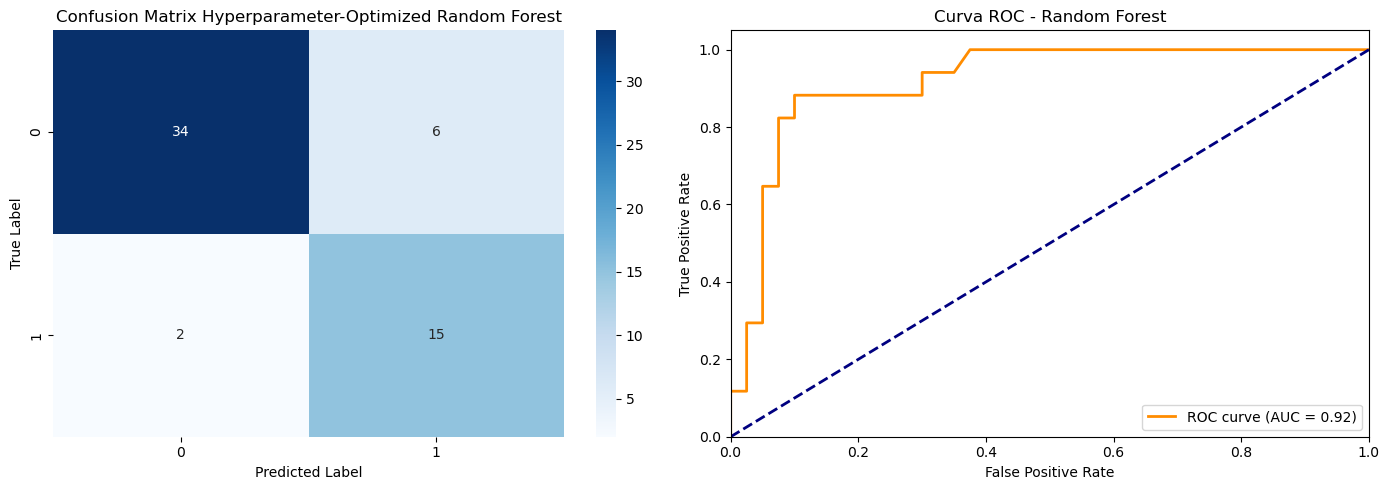

NameError: name 'step_rf' is not defined

In [13]:
print("OPTIMIZACIÓN RANDOM FOREST")

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 20), 
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_float('max_features', 0.1, 0.9),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1}
    
    model = RandomForestClassifier(**params)
    # Validacióon con variables seleccionadas
    scores = cross_val_score(model, X_train_final, y_train, cv=10, scoring='roc_auc')
    return scores.mean()
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=200) 
print("MEJORES HIPERPARÁMETROS (Random Forest):")
mejores_params_rf = study_rf.best_params
mejores_params_rf.update({'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1})
#Pipeline Final
final_pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(**mejores_params_rf))
])
#Evaluar
modelo_rf_entrenado, probs_rf = evaluar_modelo_completo(
    "Random Forest", 
    final_pipeline_rf, 
    X_train_final, y_train, 
    X_test_final, y_test
)

resultados_roc["Random Forest"] = probs_rf

#GRÁFICO SHAP
step_scaler = modelo_rf_entrenado.named_steps['scaler']
X_test_scaled = step_scaler.transform(X_test_final)
X_test_shap_df = pd.DataFrame(X_test_scaled, columns=X_test_final.columns)
explainer = shap.TreeExplainer(step_rf)
shap_values = explainer.shap_values(X_test_shap_df, check_additivity=False)
import numpy as np
if isinstance(shap_values, list):
    print("Lista (Sklearn estándar)")
    vals_to_plot = shap_values[1]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    print("Array 3D")
    vals_to_plot = shap_values[:, :, 1]
else:
    print("Formato estándar")
    vals_to_plot = shap_values

#Graficar
plt.figure(figsize=(10, 6))
plt.title("Impacto de Variables (SHAP) - Random Forest")
shap.summary_plot(vals_to_plot, X_test_shap_df, show=False)
plt.show()

[I 2026-02-23 17:22:23,996] A new study created in memory with name: no-name-dd69451f-6e97-47af-90d0-6eaef06f63c0


OPTIMIZACIÓN XGBOOST


[I 2026-02-23 17:22:25,170] Trial 0 finished with value: 0.8152354691876751 and parameters: {'n_estimators': 867, 'max_depth': 19, 'learning_rate': 0.10480424519303426, 'subsample': 0.8671725206855085, 'colsample_bytree': 0.6399037832269467, 'gamma': 1.9283501090663617}. Best is trial 0 with value: 0.8152354691876751.
[I 2026-02-23 17:22:26,700] Trial 1 finished with value: 0.7755252100840335 and parameters: {'n_estimators': 1405, 'max_depth': 8, 'learning_rate': 0.28983204246531924, 'subsample': 0.5702543459329686, 'colsample_bytree': 0.7277274860847738, 'gamma': 1.5920047319672586}. Best is trial 0 with value: 0.8152354691876751.
[I 2026-02-23 17:22:28,576] Trial 2 finished with value: 0.7979210434173669 and parameters: {'n_estimators': 1803, 'max_depth': 17, 'learning_rate': 0.09542175674944603, 'subsample': 0.5298806266966389, 'colsample_bytree': 0.916306973067186, 'gamma': 4.29792846266005}. Best is trial 0 with value: 0.8152354691876751.
[I 2026-02-23 17:22:29,504] Trial 3 finish

MEJORES HIPERPARÁMETROS (XGBoost):
{'n_estimators': 1262, 'max_depth': 3, 'learning_rate': 0.01684300362982156, 'subsample': 0.9380666659553626, 'colsample_bytree': 0.9774683604439421, 'gamma': 4.993961322143509}

RESULTADOS: XGBoost

TRAIN
AUC: 0.9381
Accuracy: 0.8584
F1-Score: 0.7808

TEST
AUC: 0.9581
Accuracy: 0.9123
F1-Score: 0.8649
--------------------------------------------------
Report (Test):
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        40
           1       0.80      0.94      0.86        17

    accuracy                           0.91        57
   macro avg       0.89      0.92      0.90        57
weighted avg       0.92      0.91      0.91        57



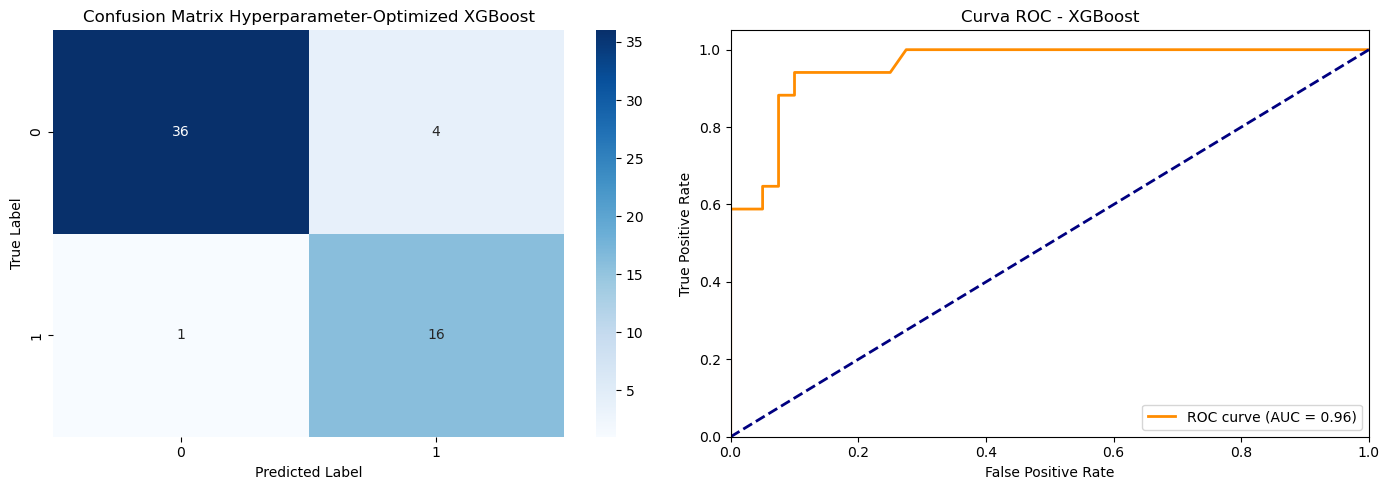

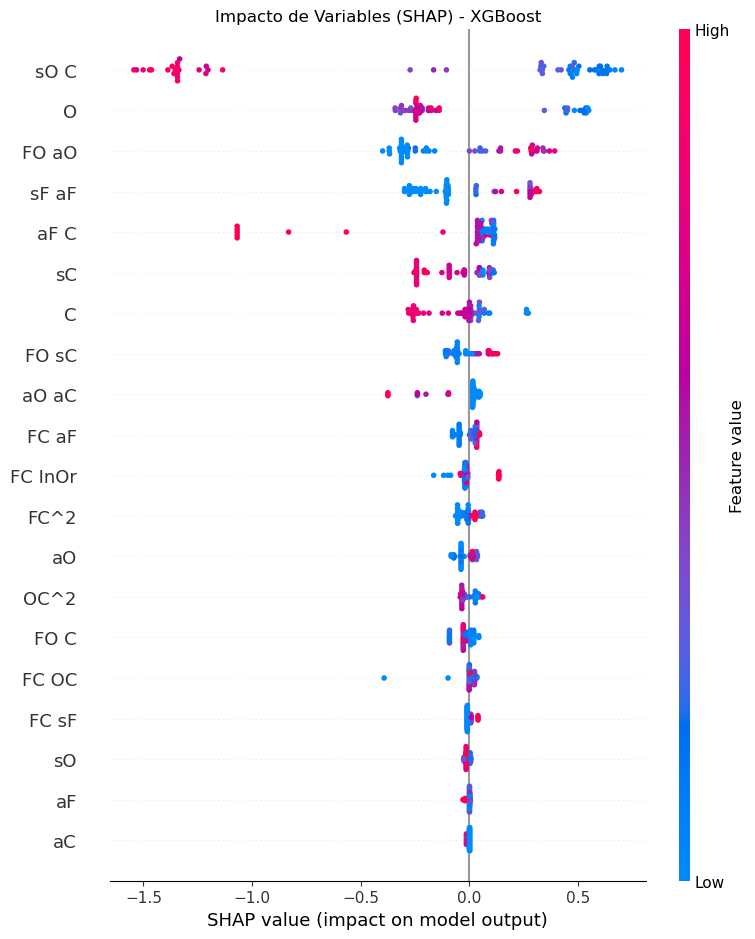

In [14]:
print("OPTIMIZACIÓN XGBOOST")

#ratio de desbalance para scale_pos_weight
ratio_desbalance = float(y_train.value_counts()[0]) / y_train.value_counts()[1]

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 20), 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight': ratio_desbalance, 
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0 }
    clf = Pipeline([
        ('scaler', StandardScaler()), 
        ('xgb', XGBClassifier(**params))
    ])
    
    # Validación cruzada con las variables seleccionadas
    scores = cross_val_score(clf, X_train_final, y_train, cv=10, scoring='roc_auc')
    
    return scores.mean()

#Optuna
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=200) 

print("MEJORES HIPERPARÁMETROS (XGBoost):")
print(study_xgb.best_params)
best_params_xgb = study_xgb.best_params
best_params_xgb.update({
    'scale_pos_weight': ratio_desbalance, 
    'eval_metric': 'logloss', 
    'random_state': 42, 
    'n_jobs': -1,
    'verbosity': 0})
final_pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()), 
    ('xgb', XGBClassifier(**best_params_xgb))])

#Evaluar resultados usando las variables lasso
modelo_xgb_entrenado, probs_xgb = evaluar_modelo_completo(
    "XGBoost", 
    final_pipeline_xgb, 
    X_train_final, y_train, 
    X_test_final, y_test
)
resultados_roc["XGBoost"] = probs_xgb

#GRAFICO SHAP XGBOOST
step_xgb = final_pipeline_xgb.named_steps['xgb']
step_scaler = final_pipeline_xgb.named_steps['scaler']
X_test_scaled = step_scaler.transform(X_test_final)
X_test_shap_df = pd.DataFrame(X_test_scaled, columns=X_test_final.columns)
explainer = shap.TreeExplainer(step_xgb)
shap_values = explainer.shap_values(X_test_shap_df)

#Graficar
plt.figure(figsize=(10, 6))
plt.title("Impacto de Variables (SHAP) - XGBoost")
shap.summary_plot(shap_values, X_test_shap_df, show=False)
plt.show()

[I 2026-02-23 17:29:40,906] A new study created in memory with name: no-name-95e0bf50-f046-4f90-92fc-610c18f04c17


OPTIMIZACIÓN KNN


[I 2026-02-23 17:29:43,420] Trial 0 finished with value: 0.8515625 and parameters: {'n_neighbors': 20, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 0 with value: 0.8515625.
[I 2026-02-23 17:29:43,556] Trial 1 finished with value: 0.8164128151260505 and parameters: {'n_neighbors': 27, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 0 with value: 0.8515625.
[I 2026-02-23 17:29:43,699] Trial 2 finished with value: 0.8545430672268907 and parameters: {'n_neighbors': 14, 'weights': 'uniform', 'metric': 'minkowski'}. Best is trial 2 with value: 0.8545430672268907.
[I 2026-02-23 17:29:43,838] Trial 3 finished with value: 0.7642419467787115 and parameters: {'n_neighbors': 3, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 2 with value: 0.8545430672268907.
[I 2026-02-23 17:29:43,974] Trial 4 finished with value: 0.821765581232493 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 2 with value: 0.85454306722689

MEJORES HIPERPARÁMETROS (KNN):
{'n_neighbors': 27, 'weights': 'uniform', 'metric': 'manhattan'}

RESULTADOS: KNN Optimizado

TRAIN
AUC: 0.8652
Accuracy: 0.8186
F1-Score: 0.6372

TEST
AUC: 0.8993
Accuracy: 0.8421
F1-Score: 0.7273
--------------------------------------------------
Report (Test):
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        40
           1       0.75      0.71      0.73        17

    accuracy                           0.84        57
   macro avg       0.81      0.80      0.81        57
weighted avg       0.84      0.84      0.84        57



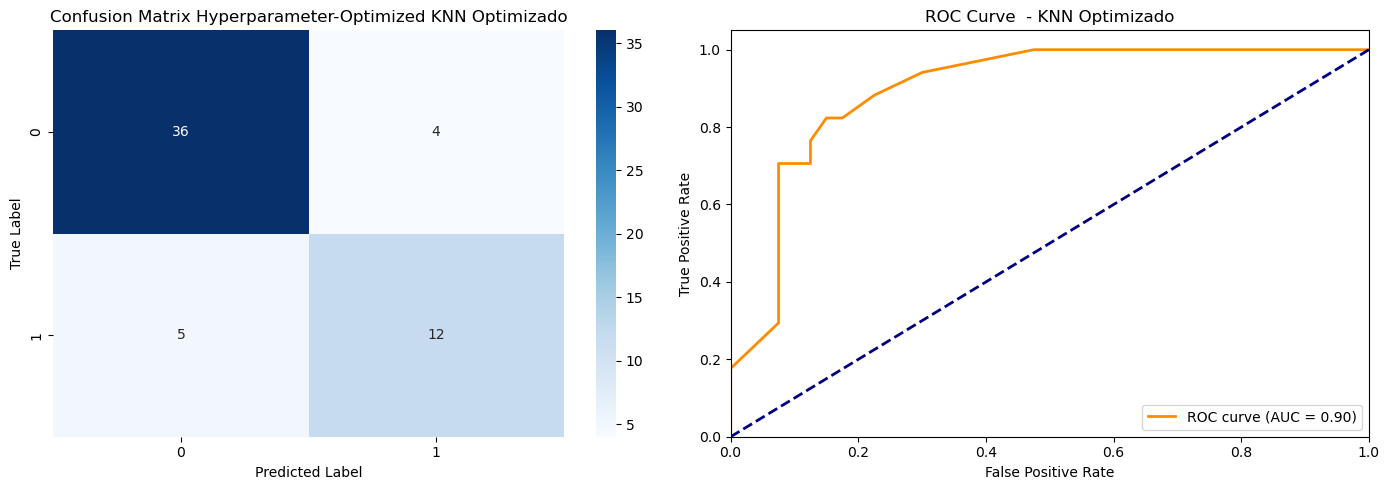

In [16]:
print("OPTIMIZACIÓN KNN")

def objective_knn(trial):
    #parámetros a probar
    n_neighbors = trial.suggest_int('n_neighbors', 3, 30)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski'])
    clf = Pipeline([
        ('scaler', StandardScaler()), 
        ('knn', KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            metric=metric,
            n_jobs=-1
        ))
    ])
    
    #Validacion cruzada variables Lasso
    scores = cross_val_score(clf, X_train_final, y_train, cv=10, scoring='roc_auc')  
    return scores.mean()

#Optuna
study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=200) 
print("MEJORES HIPERPARÁMETROS (KNN):")
print(study_knn.best_params)

#ENTRENAMIENTO FINAL
best_params_knn = study_knn.best_params
final_pipeline_knn = Pipeline([
    ('scaler', StandardScaler()), 
    ('knn', KNeighborsClassifier(
        n_neighbors=best_params_knn['n_neighbors'],
        weights=best_params_knn['weights'],
        metric=best_params_knn['metric'],
        n_jobs=-1
    ))
])

#Evaluar
modelo_knn_entrenado, probs_knn = evaluar_modelo_completo(
    "KNN Optimizado", 
    final_pipeline_knn, 
    X_train_final, y_train, 
    X_test_final, y_test
)
resultados_roc["KNN"] = probs_knn

[I 2026-02-23 17:31:32,442] A new study created in memory with name: no-name-bb1e9eb2-9ec5-429f-bbca-b1507dd4bcd6
[I 2026-02-23 17:31:32,548] Trial 0 finished with value: 0.8628326330532214 and parameters: {'C': 3.0566971757488894, 'penalty': 'l1'}. Best is trial 0 with value: 0.8628326330532214.


OPTIMIZACIÓN REGRESIÓN LOGÍSTICA


[I 2026-02-23 17:31:33,079] Trial 1 finished with value: 0.835688025210084 and parameters: {'C': 70.50351257516817, 'penalty': 'l1'}. Best is trial 0 with value: 0.8628326330532214.
[I 2026-02-23 17:31:33,138] Trial 2 finished with value: 0.5 and parameters: {'C': 0.004396217932536091, 'penalty': 'l1'}. Best is trial 0 with value: 0.8628326330532214.
[I 2026-02-23 17:31:33,234] Trial 3 finished with value: 0.8652748599439777 and parameters: {'C': 1.9539158907528487, 'penalty': 'l1'}. Best is trial 3 with value: 0.8652748599439777.
[I 2026-02-23 17:31:33,814] Trial 4 finished with value: 0.835688025210084 and parameters: {'C': 67.4611288257941, 'penalty': 'l1'}. Best is trial 3 with value: 0.8652748599439777.
[I 2026-02-23 17:31:33,882] Trial 5 finished with value: 0.8840861344537814 and parameters: {'C': 0.34259023394410526, 'penalty': 'l1'}. Best is trial 5 with value: 0.8840861344537814.
[I 2026-02-23 17:31:33,947] Trial 6 finished with value: 0.8597951680672269 and parameters: {'C':

MEJORES HIPERPARÁMETROS (Logistic Regression):
{'C': 0.8030919242323081, 'penalty': 'l1'}

RESULTADOS: Logistic Regression Optimizado

TRAIN
AUC: 0.8938
Accuracy: 0.8142
F1-Score: 0.7273

TEST
AUC: 0.8978
Accuracy: 0.8246
F1-Score: 0.7368
--------------------------------------------------
Report (Test):
              precision    recall  f1-score   support

           0       0.92      0.82      0.87        40
           1       0.67      0.82      0.74        17

    accuracy                           0.82        57
   macro avg       0.79      0.82      0.80        57
weighted avg       0.84      0.82      0.83        57



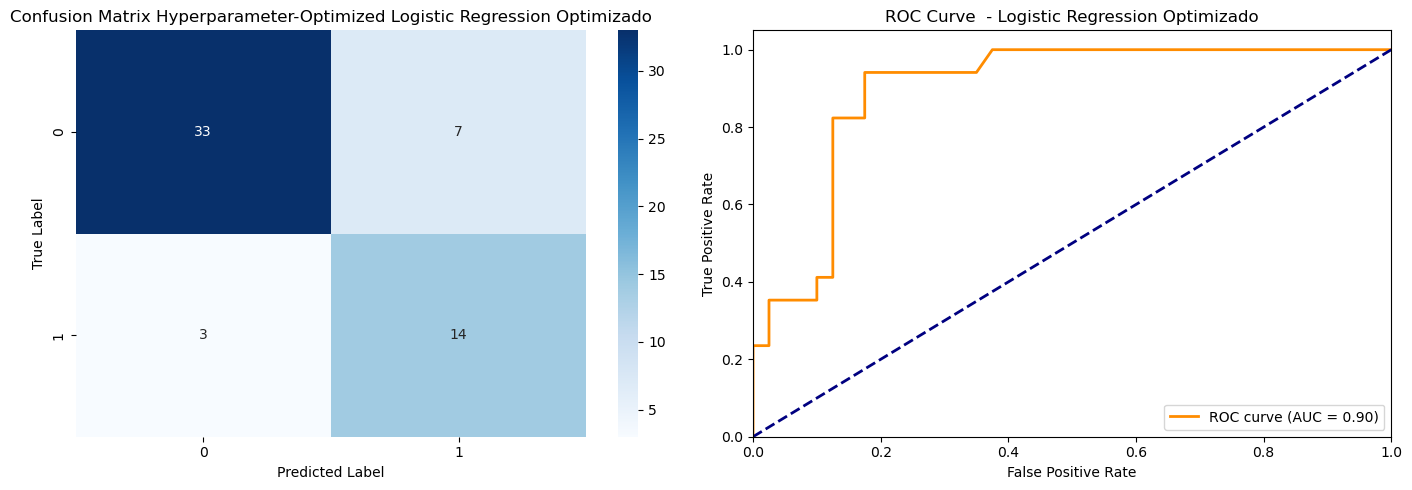

In [17]:
print("OPTIMIZACIÓN REGRESIÓN LOGÍSTICA")

def objective_lr(trial):
    #espacio de busqueda
    c_value = trial.suggest_float('C', 0.001, 100, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    params = {
        'C': c_value,
        'penalty': penalty,
        'solver': 'liblinear',       
        'class_weight': 'balanced',
        'random_state': 42}
    clf = Pipeline([
        ('scaler', StandardScaler()), 
        ('lr', LogisticRegression(**params))])
    
    #CV
    scores = cross_val_score(clf, X_train_final, y_train, cv=10, scoring='roc_auc')
    
    return scores.mean()

#Optuna
study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=200) 
print("MEJORES HIPERPARÁMETROS (Logistic Regression):")
print(study_lr.best_params)

#ENTRENAMIENTO FINAL
best_params_lr = study_lr.best_params
best_params_lr.update({
    'solver': 'liblinear', 
    'class_weight': 'balanced', 
    'random_state': 42})
final_pipeline_lr = Pipeline([
    ('scaler', StandardScaler()), 
    ('lr', LogisticRegression(**best_params_lr))])

#Evaluar
modelo_lr_entrenado, probs_lr = evaluar_modelo_completo(
    "Logistic Regression Optimizado", 
    final_pipeline_lr, 
    X_train_final, y_train, 
    X_test_final, y_test
)
resultados_roc["Logistic Regression"] = probs_lr

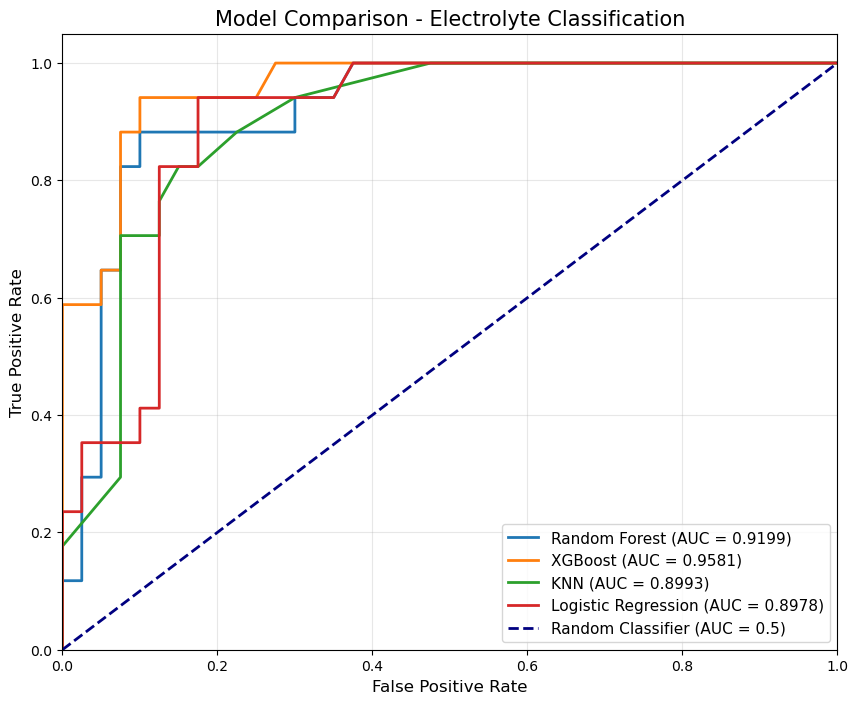

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for nombre_modelo, y_probs in resultados_roc.items():
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{nombre_modelo} (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Model Comparison - Electrolyte Classification', fontsize=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.savefig("comparación", dpi=300, bbox_inches="tight")

plt.show()